In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import kagglehub

# Downloading dataset
path = kagglehub.dataset_download("furkanercan88/5g-control-channel-transmission-dataset")

Using Colab cache for faster access to the '5g-control-channel-transmission-dataset' dataset.


In [ ]:
# Dataframe
df = pd.read_csv('/kaggle/input/5g-control-channel-transmission-dataset/dataset_shuffled.csv')

In [ ]:
# LLR (Log-Likelihood Ratio) values from each polarized AWGN channel
X = df.drop(columns=['num_errors'])
# Number of bit errors
Y = df['num_errors']

In [ ]:
# Class disbalance
class_count = Y.value_counts().sort_index()
display(class_count)

,count
num_errors,
0,79473
1,12025
2,4563
3,1971
4,993
5,474
6,236
7,120
8,74


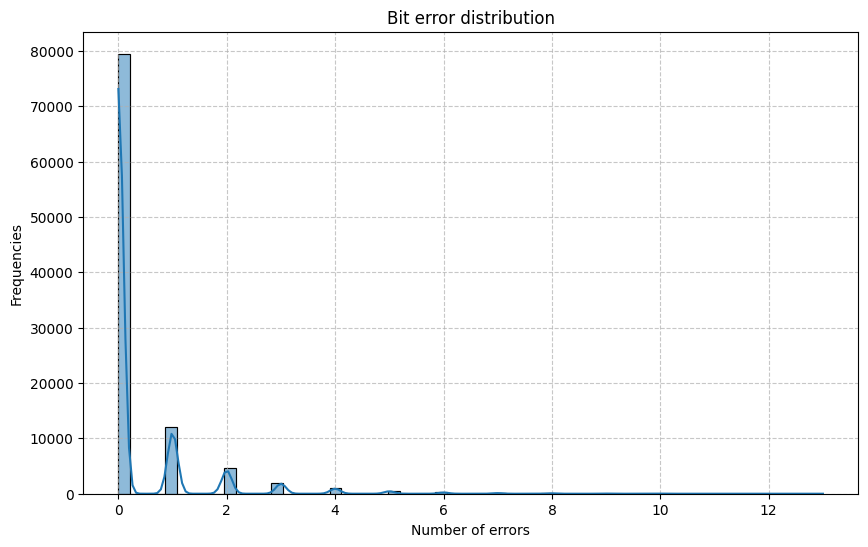

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Y (error number distribution)
plt.figure(figsize=(10, 6))
sns.histplot(df['num_errors'], bins=60, kde=True)
plt.title('Bit error distribution')
plt.xlabel('Number of errors')
plt.ylabel('Frequencies')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

In [ ]:
###########################
#### LLR data analysis ####
###########################

# Deriving channel variance dataframe
df_var = df.copy()
for col in X.columns:
    df_var[col] = np.where(
        df[col] != 0,
        np.sqrt(2 / np.abs(df[col])),
        np.inf
    )

# Renaming: llr_X -> var_X
new_columns = {col: col.replace('llr_', 'var_') for col in df_var.columns if 'llr_' in col}
df_var = df_var.rename(columns=new_columns)

In [ ]:
display(df_var.describe())

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_503,var_504,var_505,var_506,var_507,var_508,var_509,var_510,var_511,num_errors
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.075066,1.062718,1.069913,1.071953,1.065506,1.073654,1.071529,1.086178,1.086698,1.085157,...,1.057810,1.070778,1.064260,1.066382,1.062918,1.069571,1.096168,1.072516,1.067714,0.369600
std,2.241529,1.394893,1.628327,1.520492,1.476565,1.718784,2.600238,2.692330,1.531414,1.516104,...,1.689206,2.353558,1.483824,1.443867,1.548212,1.614176,5.894248,1.819896,1.598081,0.939694
min,0.373484,0.336571,0.368657,0.371577,0.360155,0.366225,0.349455,0.369082,0.354188,0.360328,...,0.370063,0.358915,0.376208,0.364866,0.371487,0.372280,0.361363,0.377318,0.361867,0.000000
25%,0.628703,0.628554,0.628832,0.630104,0.629447,0.633347,0.628380,0.631020,0.632244,0.631558,...,0.627477,0.628393,0.630269,0.632382,0.632368,0.629691,0.630888,0.628982,0.629249,0.000000
50%,0.774659,0.777152,0.774838,0.780094,0.778244,0.784187,0.781378,0.779733,0.787687,0.782793,...,0.773283,0.775708,0.778455,0.779427,0.779440,0.781323,0.781792,0.775292,0.777353,0.000000
75%,1.070286,1.073318,1.071528,1.081380,1.078100,1.082062,1.078973,1.084310,1.102467,1.087038,...,1.071838,1.069762,1.073213,1.065746,1.076694,1.080061,1.087475,1.071276,1.073321,0.000000
max,352.290710,113.690329,161.900601,139.767898,151.101800,344.108207,701.449606,660.135756,178.501857,108.926904,...,289.912318,510.752475,186.471777,102.264137,249.577247,169.127281,1646.055411,246.740272,181.863729,13.000000


/tmp/ipykernel_1936/4290117992.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


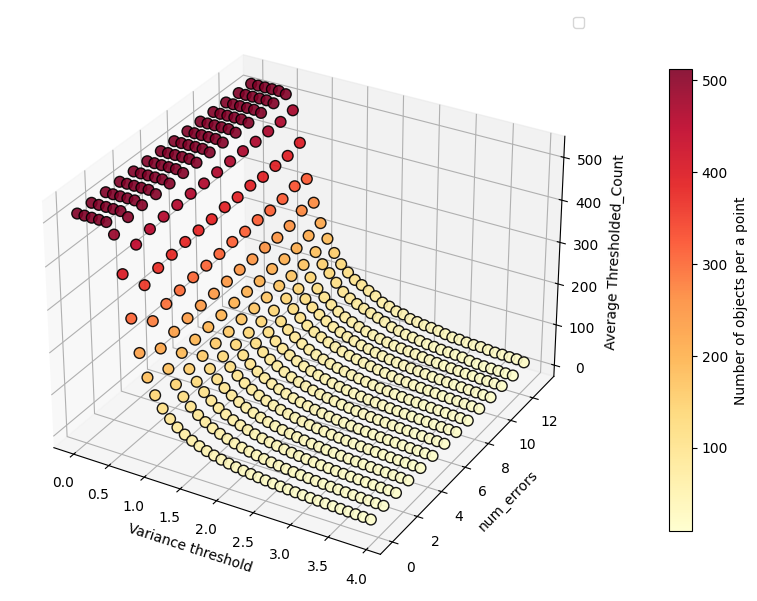

In [ ]:
x = []; y = []; z = []

# 1. Threshold for variance
for var_threshold in np.arange(0, 4, 0.1):
    # 2. Get all 'var_X' columns
    var_columns = [col for col in df_var.columns if col.startswith('var_')]

    # 3. Variance predicate
    pred_2 = (df_var[var_columns] >= var_threshold)

    # 4. Filtering across ANY rows on the predicate
    df_var = df_var[pred_2.any(axis=1)]

    # Recalculate pred_2
    pred_2 = (df_var[var_columns] >= var_threshold)

    ## Let a row's variance value be THRESHOLDED if this value is more than var_threshold
    # 5. Counting the number of thresholded values across the features (column-wise).
    thresholded_counts_features = pred_2.sum().reset_index()
    thresholded_counts_features.columns = ['Feature', 'Thresholded_Count']

    # 6. Counting the number of thresholded values across the rows (row-wise).
    thresholded_counts_rows = pred_2.sum(axis=1).to_frame(name='Thresholded_Count')
    thresholded_counts_rows = thresholded_counts_rows.merge(df_var['num_errors'], left_index=True, right_index=True)

    for num_errors in range(0, 14):
        selected_rows = thresholded_counts_rows[thresholded_counts_rows['num_errors'] == num_errors]
        avg_threshold = selected_rows['Thresholded_Count'].mean()
        x.append(var_threshold)
        y.append(num_errors)
        z.append(avg_threshold)

pts, cnt = np.unique(np.column_stack((x, y, z)), axis=0, return_counts=True)
x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
sct = ax.scatter3D(x, y, z, c = z, cmap='YlOrRd', s=cnt * 60, alpha=0.9, edgecolors='k')

cbar = fig.colorbar(sct, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Number of objects per a point')

ax.set_xlabel('Variance threshold')
ax.set_ylabel('num_errors')
ax.set_zlabel('Average Thresholded_Count')
ax.legend()

plt.show()
plt.close()

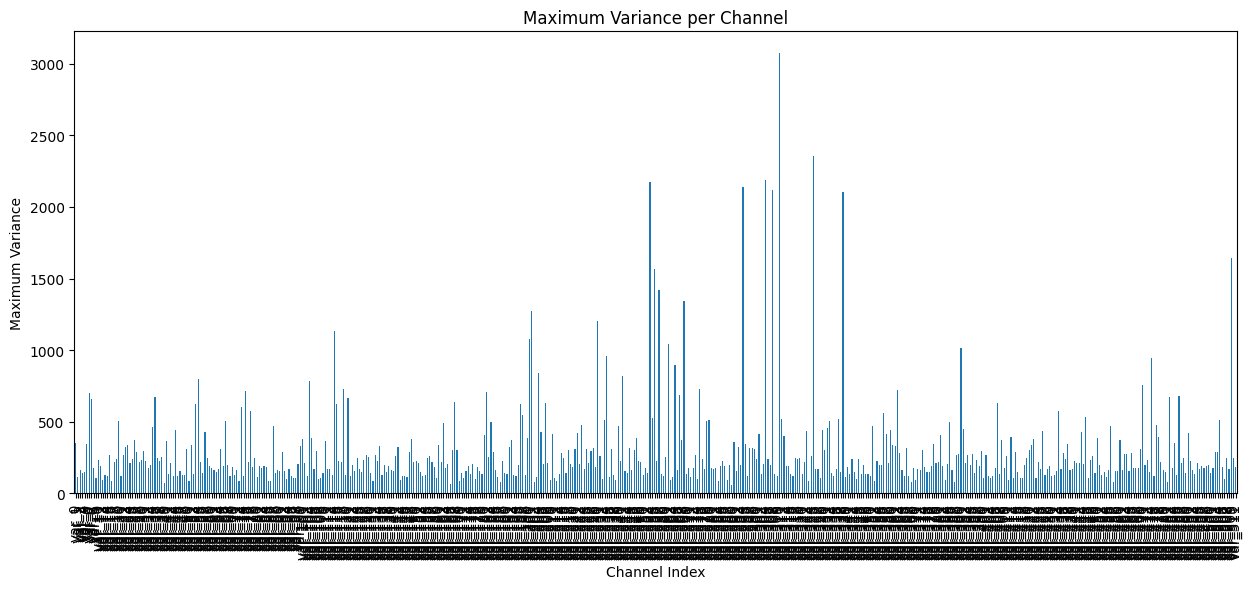

In [ ]:
df_var_desc = df_var.describe()

## All maximums for each channel
var_max = df_var_desc.loc['max']

# Filter var_max to only include columns starting with 'var_'
var_max_filtered = var_max[var_max.index.str.startswith('var_')]

plt.figure(figsize=(15, 6))
var_max_filtered.plot(kind='bar')
plt.title('Maximum Variance per Channel')
plt.xlabel('Channel Index')
plt.ylabel('Maximum Variance')
plt.show()
plt.close()

In [ ]:
## Mean for each num_error! Display a trend.
def get_interval_targets(df, num_errors, left, right):
    df_X = df[df['num_errors'] == num_errors]
    df_XX = df_X.drop(columns=['num_errors'])
    df_XX['Count'] = df_XX.apply(
        lambda row: ((left <= row) & (row <= right)).sum(),
        axis=1
    )
    return df_XX

result_count = get_interval_targets(df, 4, -0.5, 0.5)['Count'] # Check for [-0.25, 0.25]
display(result_count.describe())

,Count
count,993.000000
mean,48.699899
std,7.230408
min,29.000000
25%,44.000000
50%,49.000000
75%,53.000000
max,72.000000


In [ ]:
# Featurewise distribution histogram
def get_col_hist(df, bit_index, prefix='llr', show=False, close=True):
    column_index = f'{prefix}_{bit_index}'
    plt.clf()

    hist = sns.histplot(df[f'{column_index}'], bins=60, kde=True)

    y_values = [patch.get_height() for patch in hist.patches]
    x_lefts = [patch.get_x() for patch in hist.patches]
    widths = [patch.get_width() for patch in hist.patches]

    if (show):
        plt.show()
    if (close):
        plt.close()

    return (x_lefts, y_values)

# Objectwise distribution histogram
def get_row_hist(df, index, show=False, close=True):
    plt.clf()

    hist = sns.histplot(df.loc[index], bins=60, kde=True)

    y_values = [patch.get_height() for patch in hist.patches]
    x_lefts = [patch.get_x() for patch in hist.patches]
    widths = [patch.get_width() for patch in hist.patches]

    if (show):
        plt.show()
    if (close):
        plt.close()

    return (x_lefts, y_values)

total_results = []

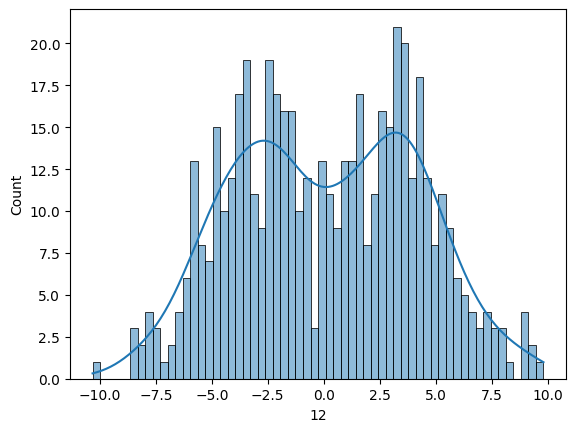

In [ ]:
x_, y_ = get_row_hist(df, 12, show=True, close=False)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

########################
### MACHINE LEARNING ###
########################

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
# Fitting with XGBoost
model = XGBRegressor(n_estimators=2000, learning_rate=0.05)
model.fit(X_train, y_train, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prediction on the training data
y_train_pred = model.predict(X_train)

# Mean Squared Error for training data
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Train Dataset Mean Squared Error: {mse_train:.4f}")

# Mean Absolute Error for training data
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f"Train Dataset Mean Absolute Error: {mae_train:.4f}")

# R-squared for training data
r2_train = r2_score(y_train, y_train_pred)
print(f"Train Dataset R-squared: {r2_train:.4f}")

Train Dataset Mean Squared Error: 0.1342
Train Dataset Mean Absolute Error: 0.2154
Train Dataset R-squared: 0.8480


In [ ]:
# Prediction of unseen targets
y_pred = model.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Test Dataset Mean Squared Error: {mse:.4f}")

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Test Dataset Mean Absolute Error: {mae:.4f}")

# R-squared
r2 = r2_score(y_test, y_pred)
print(f"Test Dataset R-squared: {r2:.4f}")

Test Dataset Mean Squared Error: 0.3719
Test Dataset Mean Absolute Error: 0.3349
Test Dataset R-squared: 0.5790


# **1. Raw dataset**

## **1.1 The first attempt (Overfitting?)**
> X_train, X_test, y_train, y_test
         = train_test_split(X, Y, test_size=0.2, random_state=42) \
> model = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

Train Dataset Mean Squared Error: 0.2346 \
Train Dataset Mean Absolute Error: 0.2902 \
Train Dataset R-squared: 0.7343

Test Dataset Mean Squared Error: 0.4395 \
Test Dataset Mean Absolute Error: 0.3771 \
Test Dataset R-squared: 0.5025

**Overfitting?**


## **1.2. The second attempt (Overfitting?)**
> X_train, X_test, y_train, y_test
         = train_test_split(X, Y, test_size=0.2, random_state=42) \
> model = XGBRegressor(n_estimators=1000, learning_rate=0.03, random_state=42)

Train Dataset Mean Squared Error: 0.3059 \
Train Dataset Mean Absolute Error: 0.3351 \
Train Dataset R-squared: 0.6535

Test Dataset Mean Squared Error: 0.4846 \
Test Dataset Mean Absolute Error: 0.4009 \
Test Dataset R-squared: 0.4513

**Overfitting?**

## **1.3. The third attempt**
> X_train, X_test, y_train, y_test
         = train_test_split(X, Y, test_size=0.2, random_state=42) \
> model = XGBRegressor(learning_rate=0.01, early_stopping_rounds=50) \
> model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

Train Dataset Mean Squared Error: 0.8218 \
Train Dataset Mean Absolute Error: 0.5590 \
Train Dataset R-squared: 0.0693

Test Dataset Mean Squared Error: 0.8325 \
Test Dataset Mean Absolute Error: 0.5592 \
Test Dataset R-squared: 0.0575

## **1.4. The fourth attempt**
> X_train, X_test, y_train, y_test
         = train_test_split(X, Y, test_size=0.2, random_state=42) \
> model = XGBRegressor(learning_rate=0.08)

Train Dataset Mean Squared Error: 0.5806 \
Train Dataset Mean Absolute Error: 0.4358 \
Train Dataset R-squared: 0.3424

Test Dataset Mean Squared Error: 0.6518 \
Test Dataset Mean Absolute Error: 0.4582 \
Test Dataset R-squared: 0.2621

## **5. The fifth attempt**
> model = XGBRegressor(n_estimators=2000, learning_rate=0.01) \
> model.fit(X_train, y_train, verbose=False)

Train Dataset Mean Squared Error: 0.3716 \
Train Dataset Mean Absolute Error: 0.3649 \
Train Dataset R-squared: 0.5791

Test Dataset Mean Squared Error: 0.5231 \
Test Dataset Mean Absolute Error: 0.4155 \
Test Dataset R-squared: 0.4078

## **6. The sixth attempt (Overfitting?)**

> model = XGBRegressor(n_estimators=2000, learning_rate=0.05)
> model.fit(X_train, y_train, verbose=False)

Train Dataset Mean Squared Error: 0.1342 \
Train Dataset Mean Absolute Error: 0.2154 \
Train Dataset R-squared: 0.8480

Test Dataset Mean Squared Error: 0.3719 \
Test Dataset Mean Absolute Error: 0.3349 \
Test Dataset R-squared: 0.5790